In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['class'] = cancer.target

In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1:].values
print(X.shape, y.shape)

(569, 30) (569, 1)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(455, 30) (114, 30) (455, 1) (114, 1)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0)
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(341, 30) (114, 30) (114, 30) (341, 1) (114, 1) (114, 1)


In [7]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [8]:
X_train_sc_tensor = torch.from_numpy(X_train_sc).float()
X_val_sc_tensor = torch.from_numpy(X_val_sc).float()
X_test_sc_tensor = torch.from_numpy(X_test_sc).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_val_tensor = torch.from_numpy(y_val).float()
y_test_tensor = torch.from_numpy(y_test).float()
print(X_train_sc_tensor.shape, X_val_sc_tensor.shape, X_test_sc_tensor.shape, y_train_tensor.shape, y_val_tensor.shape, y_test_tensor.shape)

torch.Size([341, 30]) torch.Size([114, 30]) torch.Size([114, 30]) torch.Size([341, 1]) torch.Size([114, 1]) torch.Size([114, 1])


In [10]:
model = nn.Sequential(
    nn.Linear(X_train_sc_tensor.shape[-1], 25),
    nn.LeakyReLU(),
    nn.Linear(25, 20),
    nn.LeakyReLU(),
    nn.Linear(20, 15),
    nn.LeakyReLU(),
    nn.Linear(15, 10),
    nn.LeakyReLU(),
    nn.Linear(10, 5),
    nn.LeakyReLU(),
    nn.Linear(5, y_train_tensor.shape[-1]),
    nn.Sigmoid()
)
model = model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=30, out_features=25, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=25, out_features=20, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=20, out_features=15, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=15, out_features=10, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=10, out_features=5, bias=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Linear(in_features=5, out_features=1, bias=True)
  (11): Sigmoid()
)


In [11]:
lowest_loss = np.inf
best_model = None
early_stop = 500
lowest_epoch = np.inf

In [13]:
n_epochs = 30000
batch_size = 192
learning_rate = 1e-4
print_interval = 1000

In [14]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [15]:
train_history, valid_history = [], []

for i in range(n_epochs):
    indices = torch.randperm(X_train_sc_tensor.shape[0])
    X_ = torch.index_select(X_train_sc_tensor, dim=0, index=indices).to(device)
    y_ = torch.index_select(y_train_tensor, dim=0, index=indices).to(device)

    X_ = X_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0
    y_hat = []

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = F.binary_cross_entropy(y_hat_i, y_i)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += float(loss.detach())
    
    train_loss = train_loss / len(X_)

    with torch.no_grad():
        X_ = X_val_sc_tensor.to(device).split(batch_size, dim=0)
        y_ = y_val_tensor.to(device).split(batch_size, dim=0)

        for X_i, y_i in zip(X_, y_):
            y_hat_i = model(X_i)
            loss = F.binary_cross_entropy(y_hat_i, y_i)

            valid_loss += float(loss.detach())

            y_hat += [y_hat_i]
        
        valid_loss = valid_loss / len(X_)
    
    train_history += [train_loss]
    valid_history += [valid_loss]

    if (i + 1) % print_interval == 0:
        print(f'Epoch {i + 1}: train loss={train_loss:.4f}, valid loss={valid_loss:.4f}, lowest loss={lowest_loss:.4f}')
    
    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i + 1:
            print(f'There is no improvement during last {early_stop} epochs.')
            break

print(f'The best validation loss from epoch {lowest_epoch + 1}: {lowest_loss:.4f}')

model.load_state_dict(best_model)

Epoch 1000: train loss=0.0254, valid loss=0.1349, lowest loss=0.0736
There is no improvement during last 500 epochs.
The best validation loss from epoch 591: 0.0736


<All keys matched successfully>

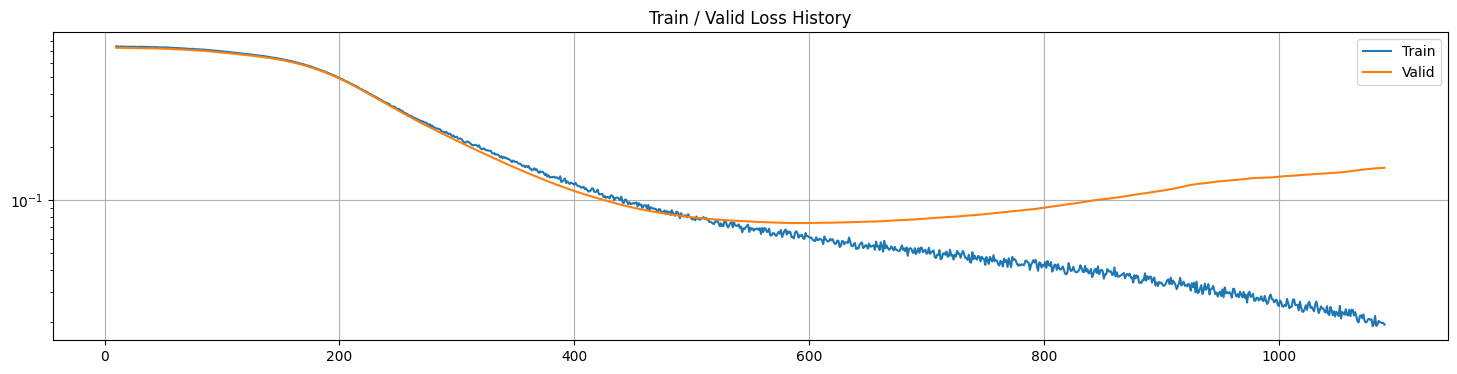

In [21]:
plot_from = 10

fig, ax = plt.subplots(1, 1, figsize=(18, 4))
plt.title('Train / Valid Loss History')
ax.plot(range(plot_from, len(train_history)), train_history[plot_from:],
         range(plot_from, len(valid_history)), valid_history[plot_from:])
plt.grid(True)
plt.yscale('log')
plt.legend(['Train', 'Valid'])
plt.show()

In [22]:
test_loss = 0
y_hat = []

with torch.no_grad():
    X_ = X_test_sc_tensor.to(device).split(batch_size, dim=0)
    y_ = y_test_tensor.to(device).split(batch_size, dim=0)

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = F.binary_cross_entropy(y_hat_i, y_i)

        test_loss += float(loss.detach())

        y_hat += [y_hat_i]
    
    test_loss = test_loss / len(X_)

y_hat = torch.concat(y_hat, dim=0)

In [23]:
sorted_history = sorted(zip(train_history, valid_history), key=lambda x: x[1])

print(f'Train loss: {sorted_history[0][0]:.4f}')
print(f'Valid loss: {sorted_history[0][1]:.4f}')
print(f'Test loss: {test_loss:.4f}')

Train loss: 0.0647
Valid loss: 0.0736
Test loss: 0.1416


In [27]:
correct_cnt = (y_test_tensor == (y_hat.to('cpu') > 0.5)).sum()
total_cnt = y_test_tensor.shape[0]

print(f'Test Accuracy: {correct_cnt / total_cnt:.2f}')

Test Accuracy: 0.96


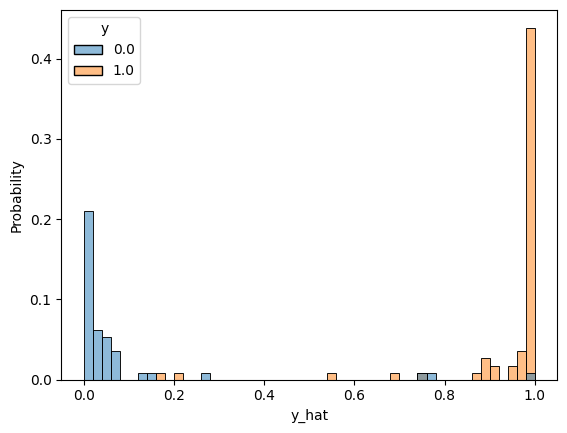

In [28]:
df = pd.DataFrame(torch.concat([y_hat.to('cpu'), y_test_tensor], dim=1).detach().numpy(), columns=['y_hat', 'y'])
sns.histplot(df, x='y_hat', hue='y', bins=50, stat='probability')
plt.show()

In [34]:
df = pd.DataFrame(torch.concat([y_hat.to('cpu') > 0.5, y_test_tensor], dim=1).detach().numpy(), columns=['y_hat', 'y'])
roc_auc_score(df.values[:, 0], df.values[:, 1])

0.9562020460358057